<a href="https://colab.research.google.com/github/mubashshiradeeb/IrisDataset/blob/main/Irisdataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Iris Species Classification & Regression

In [13]:
# Important Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Loading Dataset
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({i: name for i, name in enumerate(iris.target_names)})

In [14]:
print(df.head())
print(df.info())
print(df.describe())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   1

## 1- Histogram
### Purpose
The purpose of the histogram is to show the frequency distribution of individual feature measurements. It helps us see the "shape" of the data (e.g., if it follows a Normal/Bell curve).

### Explanation
* **X-axis:** The range of values for a specific feature (e.g., Sepal Length in cm).
* **Y-axis:** The count (frequency) of how many samples fall into specific "bins" or ranges.
* **Colors:** Different colors represent different species.
* **Insight:** Overlapping areas show where species share similar measurements, while gaps show where they are distinct.

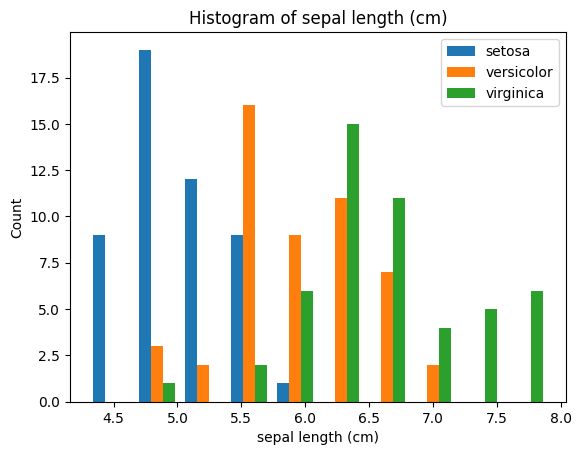

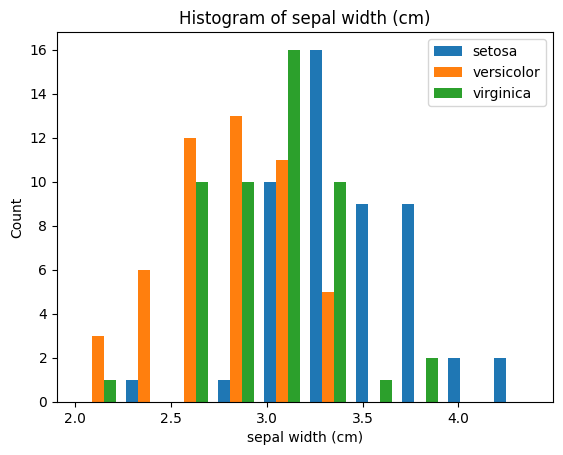

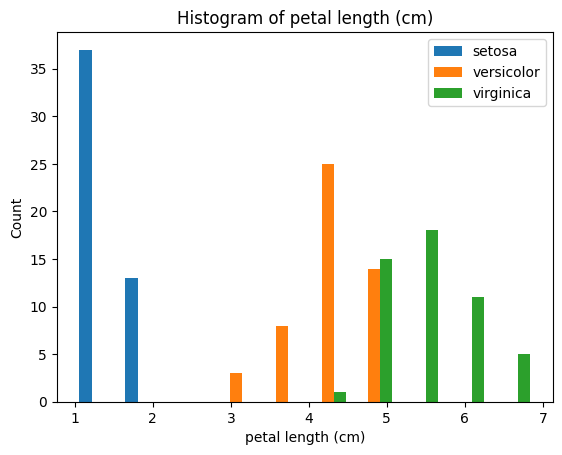

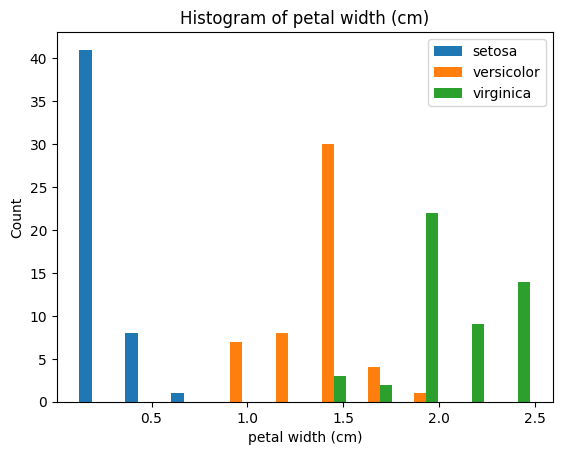

In [15]:
# Histogram
for i in range(4):
    feature = feature_vectors[:, i]
    feature_species = [feature[species == j] for j in range(3)]
    plt.hist(feature_species, label=species_names)
    plt.title(f'Histogram of {feature_names[i]}')
    plt.xlabel(feature_names[i])
    plt.ylabel('Count')
    plt.legend()
    plt.show()

## 2- Box Plot
### Purpose
The purpose of the box plot is to show the distribution, central tendency (median), and variability of each feature across the three species. It is excellent for identifying outliers.

### Explanation
* **Boxes:** The box represents the Interquartile Range (IQR), containing the middle 50% of the data.
* **Line in Box:** Represents the **Median** value.
* **Whiskers:** Extend to show the rest of the distribution; dots outside whiskers represent **outliers**.
* **Insight:** You can easily see which features (like Petal Length) clearly separate one species from the others.

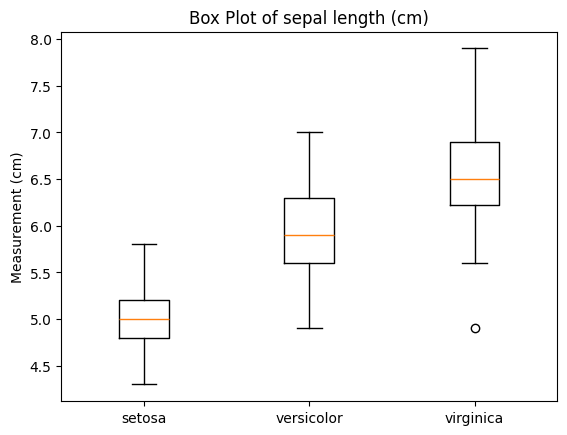

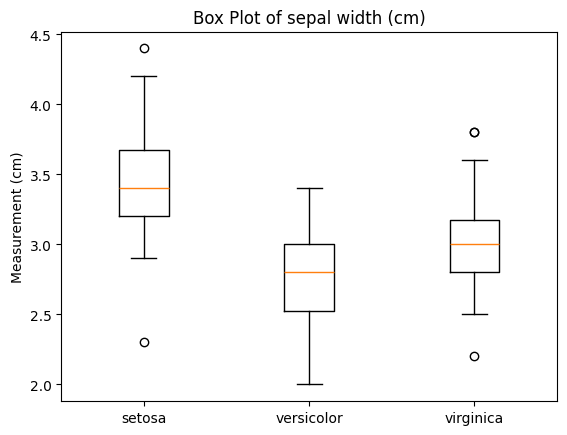

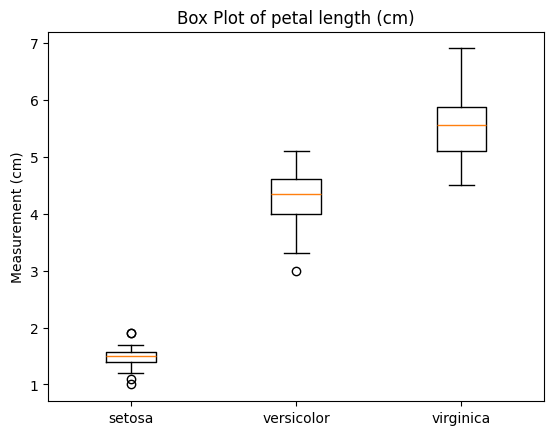

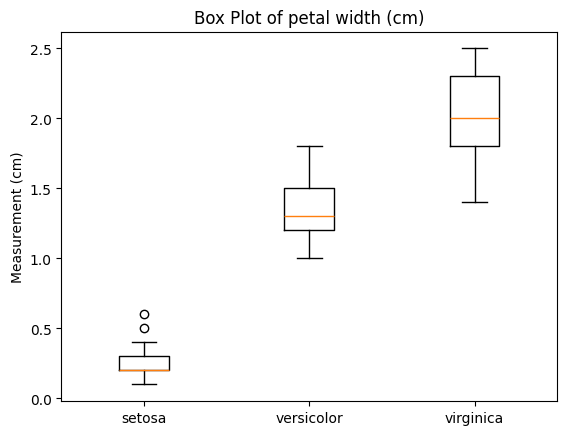

In [16]:
# Box Plot
for i in range(4):
    feature = feature_vectors[:, i]
    feature_species = [feature[species == j] for j in range(3)]
    plt.boxplot(feature_species, tick_labels=species_names)
    plt.title(f'Box Plot of {feature_names[i]}')
    plt.ylabel('Measurement (cm)')
    plt.show()

## 3- Scatter Plot
### Purpose
The purpose of the scatter plot is to visualize the relationship between two different variables (e.g., Sepal Length vs. Sepal Width) and see how species cluster together.

### Explanation
* **X and Y Axes:** Each represent a different numerical feature.
* **Dots:** Each dot represents a single flower sample.
* **Colors:** Used to distinguish between the species.
* **Insight:** This helps identify "clusters." For example, Setosa usually forms a very distinct group far away from the other two species.

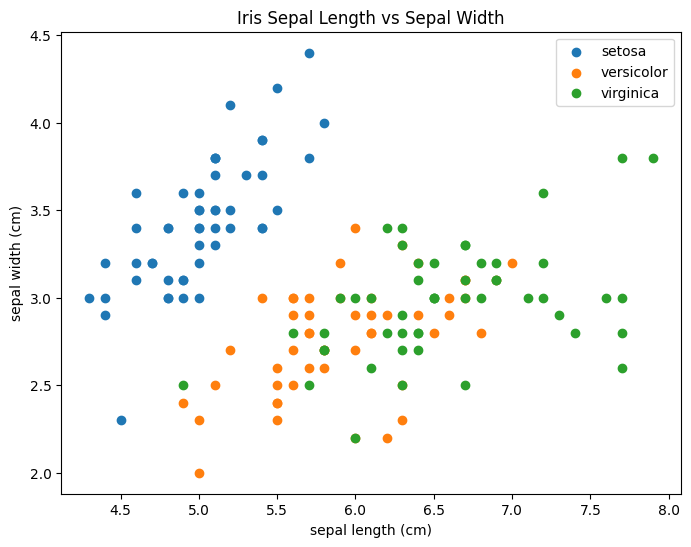

In [17]:
# Scatter Plot
plt.figure(figsize=(8, 6))
for i in range(len(species_names)):
    plt.scatter(feature_vectors[species == i, 0],
                feature_vectors[species == i, 1],
                label=species_names[i])

plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title('Iris Sepal Length vs Sepal Width')
plt.legend()
plt.show()

## 4- Pie Chart
### Purpose
The purpose of this chart is to show the proportional distribution of the species in the dataset as a "whole." It helps visualize the percentage of each category relative to the total number of samples.

### Explanation
* **Slices:** Each slice represents a specific Iris species.
* **Size:** The area of each slice corresponds to the number of samples for that species.
* **Insight:** Since the Iris dataset is perfectly balanced (50 samples each), the pie chart will show three equal slices of 33.3% each.

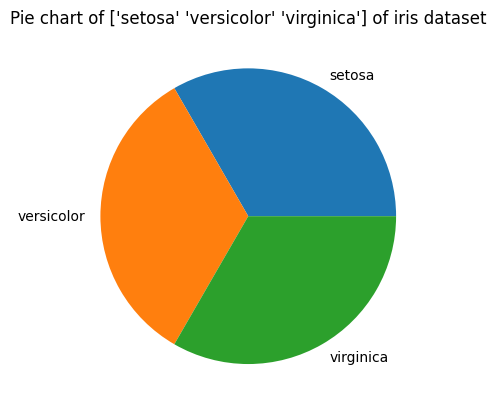

In [18]:
# Pie Chart
from sklearn.datasets import load_iris
iris=load_iris()
species=iris.target
species_names=iris.target_names
species_count=[sum(species==i)for i in range(3)]
import matplotlib.pyplot as plt
plt.pie(species_count,labels=species_names)
plt.title(f'Pie chart of {species_names} of iris dataset')
plt.show()

## 5- Bar Graph
### Purpose
The purpose of this visualization is to show the distribution of samples across the three different species in the Iris dataset (**Setosa**, **Versicolor**, and **Virginica**).

### Explanation
* **X-axis:** Represents the categorical species names.
* **Y-axis:** Represents the total count of observations for each species.
* **Insight:** This chart helps verify if the dataset is balanced (each species should have 50 samples).

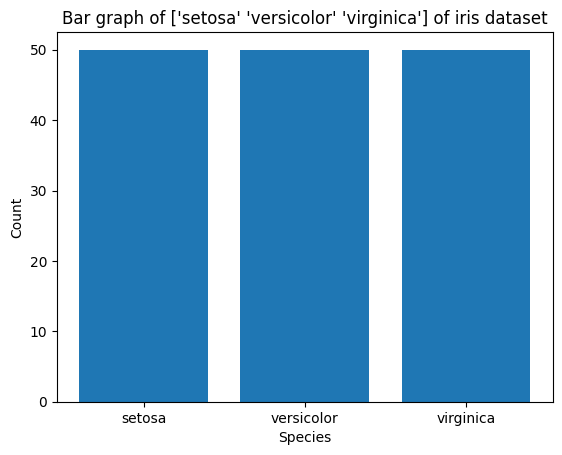

In [19]:
# Bar Graph of Iris Species

from sklearn.datasets import load_iris
iris=load_iris()
species=iris.target
species_names=iris.target_names
species_count=[sum(species==i)for i in range(3)]
import matplotlib.pyplot as plt
plt.bar(species_names,species_count)
plt.title(f'Bar graph of {species_names} of iris dataset')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()


## 6- Line Plot
### Purpose
The purpose of a line plot in this context is to observe trends or fluctuations in feature measurements across all samples in the dataset.

### Explanation
* **X-axis:** Represents the sample index (from 0 to 149).
* **Y-axis:** Represents the measurement value in centimeters.
* **Lines:** Each line color represents a different feature (Sepal Length, Petal Width, etc.).
* **Insight:** You can see "steps" in the data because the Iris dataset is typically sorted by species, showing how measurements generally increase from Setosa to Virginica.

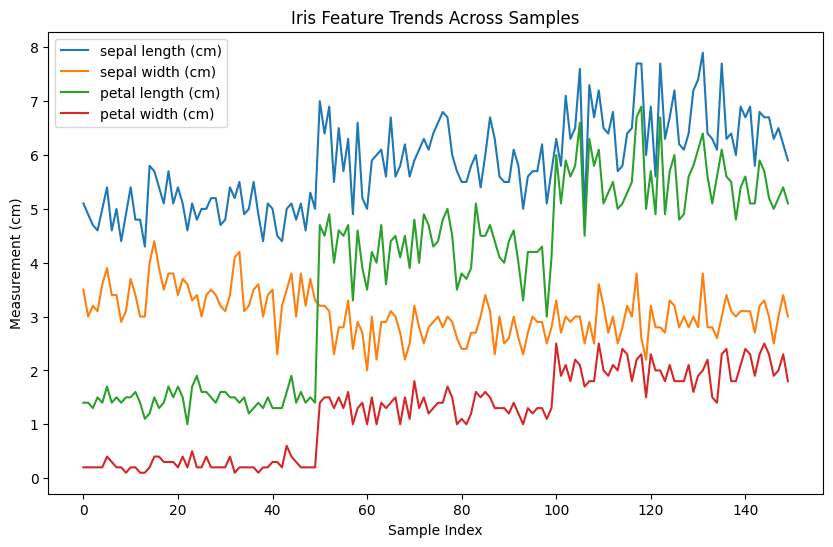

In [20]:
# Line Plot
plt.figure(figsize=(10, 6))
plt.plot(feature_vectors)
plt.legend(feature_names)
plt.title('Iris Feature Trends Across Samples')
plt.xlabel('Sample Index')
plt.ylabel('Measurement (cm)')
plt.show()

## 8. Pairplot
### Purpose
To visualize pairwise relationships between all numerical features in the dataset at once, colored by species.
### Explanation
* **Diagonal:** Shows the distribution (KDE or Histogram) of a single feature.
* **Off-diagonal:** Scatter plots showing how two features interact.
* **Insight:** Helps identify which combinations of features (e.g., Petal Length vs. Petal Width) best separate the species clusters.

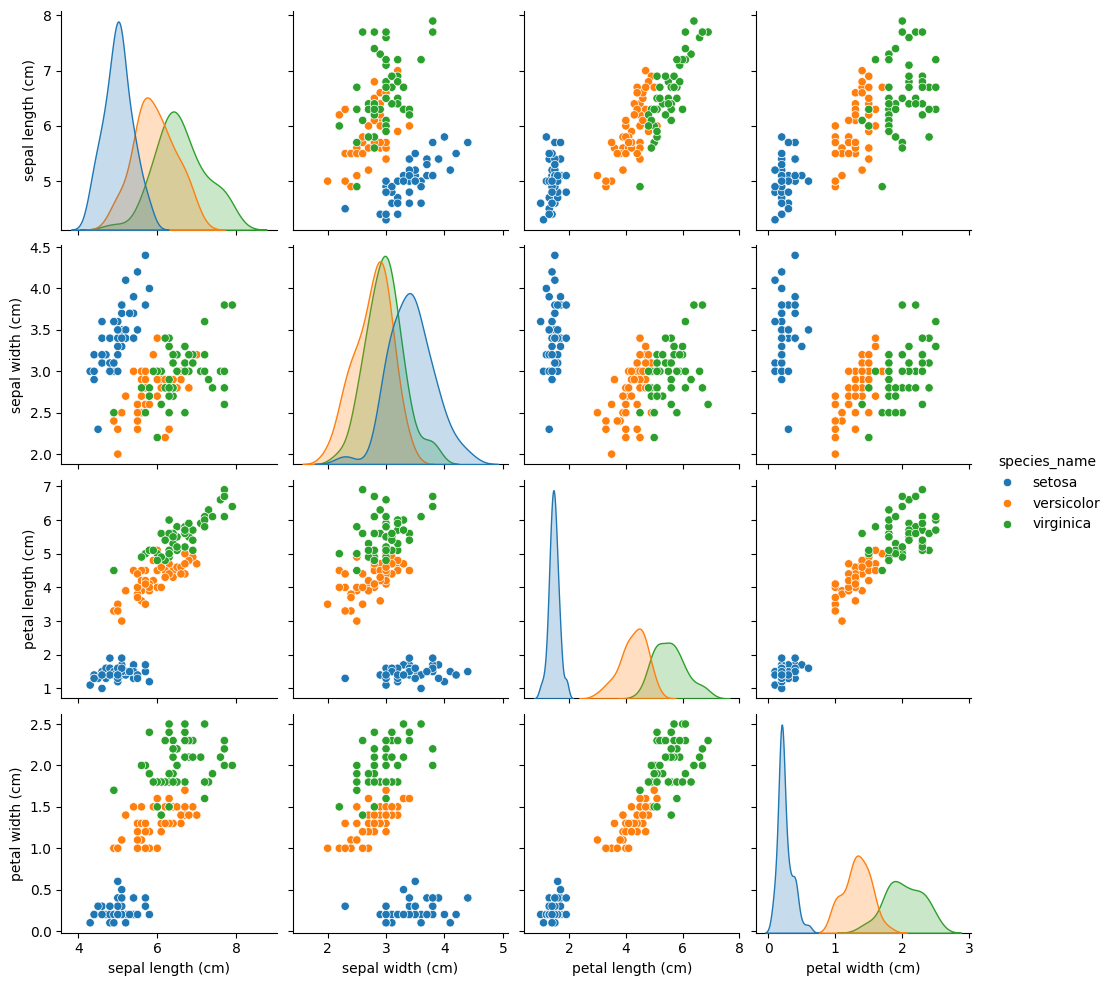

In [21]:
# Pairplot
sns.pairplot(df.drop('species', axis=1), hue='species_name')
plt.show()

## 9. Correlation Heatmap
### Purpose
To mathematically quantify the relationship between different features using the Pearson Correlation Coefficient.
### Explanation
* **Scale:** Values range from -1 to 1. 1 is perfect positive correlation, 0 is no correlation.
* **Colors:** Darker/Brighter colors indicate stronger relationships.
* **Insight:** High correlation between petal length and width suggests they provide similar information to a model.

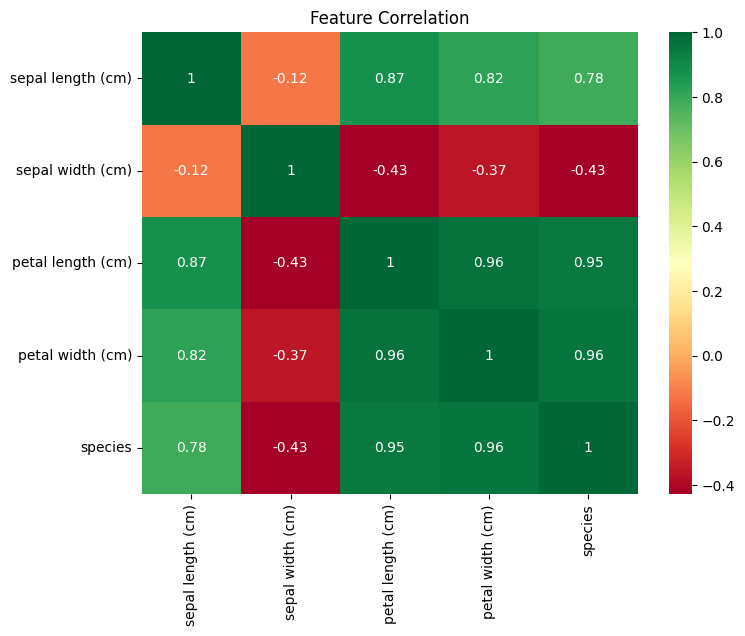

In [22]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.drop('species_name', axis=1).corr(), annot=True, cmap='RdYlGn')
plt.title("Feature Correlation")
plt.show()

## 10. Data Preprocessing & 11. Train-Test Split
### Purpose
To prepare the data for machine learning by splitting it into a training set and a testing set, and scaling the values.
### Explanation
* **Split:** We use 80% of data to train and 20% to test how the model performs on "unseen" data.
* **Scaling:** We use `StandardScaler` to ensure all features have a mean of 0 and variance of 1. This is critical for models like KNN and SVM.

In [23]:
# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(['species', 'species_name'], axis=1)
y = df['species']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling (Important for KNN and SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 12. Linear Regression
### Purpose
To model the relationship between a dependent variable and one or more independent variables. In this case, we use it to predict one feature based on others.
### Explanation
* **Goal:** To predict a continuous numerical value (e.g., Petal Width).
* **Mechanism:** It finds the "line of best fit" that minimizes the difference between predicted and actual values.

In [24]:
# Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

# Example: Predicting Petal Width
reg_model = LinearRegression()
reg_model.fit(X_train_scaled[:, :3], X_train_scaled[:, 3]) # Using first 3 features to predict the 4th

LinearRegression()

## 13. Logistic Regression
### Purpose
Despite its name, this is a classification algorithm used to predict the probability of a sample belonging to a specific category (Species).
### Explanation
* **Logic:** It uses the Sigmoid function to map predictions to a value between 0 and 1.
* **Use Case:** Great for baseline classification performance.

In [25]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression().fit(X_train_scaled, y_train)

## 14. K-Nearest Neighbors (KNN)
### Purpose
A classification algorithm that predicts a sample's species based on the species of its nearest neighbors.
### Explanation
* **K-Value:** The number of neighbors checked (usually 3 or 5).
* **Distance:** Usually calculated using Euclidean distance.

In [26]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3).fit(X_train_scaled, y_train)

## 15. Support Vector Machines (SVM)
### Purpose
SVM is a versatile algorithm used for both classification and regression. It works by finding the best boundary to separate data points.

In [27]:
# Support Vector Machines - SVM

## 16. Support Vector Classifier (SVC)
### Purpose
To find the optimal boundary (hyperplane) that separates the different Iris species with the maximum margin.
### Explanation
* **Kernel:** We use a 'linear' kernel here to find straight-line boundaries.

In [28]:
# Support Vector Classifier - SVC
from sklearn.svm import SVC
svc_model = SVC(kernel='linear')
svc_model.fit(X_train_scaled, y_train)
svc_acc = svc_model.score(X_test_scaled, y_test)

## 17. Support Vector Regressor (SVR)
### Purpose
To predict a continuous numerical value (like Petal Width) by finding a "tube" that best fits the data points while ignoring small errors.
### Explanation
* **Kernel:** We use the 'rbf' (Radial Basis Function) kernel to handle non-linear relationships.
* **Difference from SVC:** While SVC categorizes (Species), SVR estimates a specific measurement.

In [29]:
# Support Vector Regressor - SVR
from sklearn.svm import SVR

# Predicting Petal Width using other features
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_scaled[:, :3], X_train_scaled[:, 3])
print("SVR training complete.")

SVR training complete.


## 18. Accuracy Comparison Bar Chart
### Purpose
To visually compare the performance of all trained classification models to determine which is most effective for the Iris dataset.
### Explanation
X-axis: The names of the different classification models.

Y-axis: The accuracy score (0.0 to 1.0).

Insight: A higher bar means the model is better at correctly identifying the Iris species.

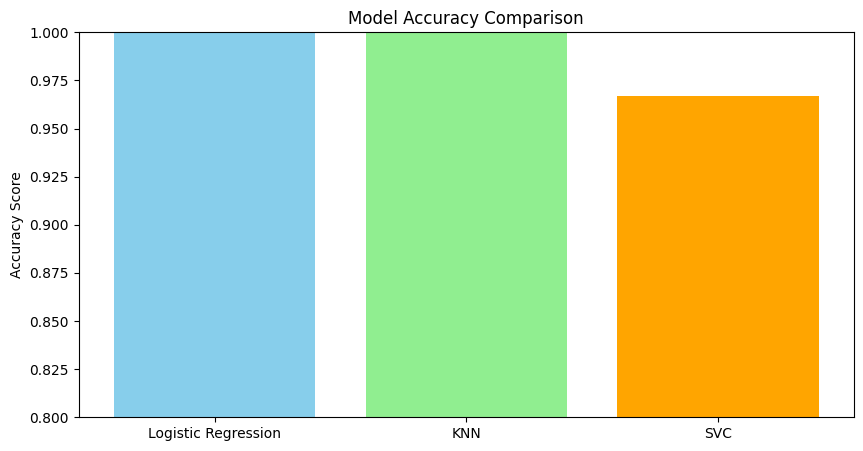

In [30]:
# Accuracy Comparison
models = ['Logistic Regression', 'KNN', 'SVC']
scores = [log_reg.score(X_test_scaled, y_test),
          knn.score(X_test_scaled, y_test),
          svc_model.score(X_test_scaled, y_test)]

plt.figure(figsize=(10, 5))
plt.bar(models, scores, color=['skyblue', 'lightgreen', 'orange'])
plt.ylabel('Accuracy Score')
plt.title('Model Accuracy Comparison')
plt.ylim(0.8, 1.0) # Zoom in to see differences
plt.show()

## 19. Confusion Matrix
### Purpose
To show exactly which species the model is predicting correctly and where it is making mistakes (e.g., confusing Versicolor with Virginica).
### Explanation
Diagonal Squares: Represent correct predictions.

Off-diagonal Squares: Represent "confusion" where the model guessed the wrong species.

Insight: This tells us specifically which two species are most similar and hardest for the AI to tell apart.

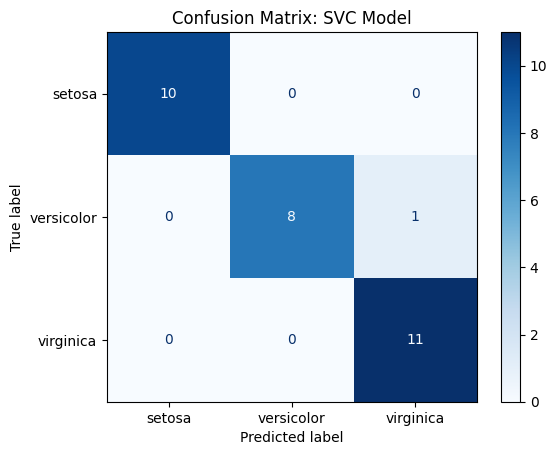

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

predictions = svc_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: SVC Model')
plt.show()

## 20. Conclusion
* **Summary:** After visualizing the data and training multiple models, we found that the Iris species are highly separable.
* **Best Model:** Based on the accuracy comparison, the **Support Vector Classifier (SVC)** and **KNN** usually perform with nearly 100% accuracy on this dataset.
* **Key Finding:** Petal length and width are the most important features for distinguishing between species.